In [1]:
import importlib

import gspf_ilp
importlib.reload(gspf_ilp)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from galois import GF2
import tableau as ta

from gspf_ilp import generalised_spf_logical
from spf_graphs import crazy_graph, sample_lost_nodes
from decoder_methods import create_graph_code
from spf_graphs import triangular_lattice, hexagonal_lattice, square_lattice

In [ ]:

g = crazy_graph(4,4)
g = nx.to_numpy_array(g, dtype = np.uint16)
#numq = g.shape[0]-1
xlogi, zlogi, stabi = create_graph_code(g)
T = GF2(stabi)
numq=T.shape[1]//2
gg = 1
previous_meas = []
previous_meas = [ta.paulistring2tableau(ele, numq) for ele in previous_meas]


fail_list = []
fit = []
num_shots = 5_00

lost_prob = np.linspace(0,1,21)
for p in lost_prob:
    print(p)
    fail = 0

    for ele in range(num_shots):
        lq = sample_lost_nodes(g, p)
        lost_cols = [node - 1 for node in lq]
        lost_qubits = [0]*2*numq
        for c in lost_cols:
            lost_qubits[c] = 1
            lost_qubits[c+numq] = 1

        res = generalised_spf_logical(stabi, xlogi, zlogi, previous_meas, lost_qubits, gg, target_qubit=numq-1)
        if res["success"]:
            fail += 1

    fail_list.append(fail/num_shots)
    fit.append((1-p**4)**4)

fail_list = np.asarray(fail_list)
yerr =  np.sqrt(fail_list * (1 - fail_list) / num_shots)

plt.figure()
plt.title("Threshold plot for crazy graph")
# plt.plot(lost_prob, fail_list)
plt.errorbar(lost_prob, fail_list, yerr=yerr, fmt = "o-", label = "g-SPF")
plt.plot(lost_prob, fit, label = r"Fit $(1-p^{4})^{4}$")
plt.legend()
plt.show()

In [ ]:

plt.figure()
for i in [2,3,4, 5]:

    g = triangular_lattice(i,i)
    g = nx.to_numpy_array(g, dtype = np.uint16)
    #numq = g.shape[0]-1
    xlogi, zlogi, stabi = create_graph_code(g)
    T = GF2(stabi)
    numq=T.shape[1]//2
    gg = 1
    previous_meas = []
    previous_meas = [ta.paulistring2tableau(ele, numq) for ele in previous_meas]


    fail_list = []
    fit = []
    num_shots = 2000


    lost_prob = np.linspace(0,1,21)
    for p in lost_prob:
        # print(p)
        fail = 0

        for ele in range(num_shots):
            lq = sample_lost_nodes(g, p)
            lost_cols = [node - 1 for node in lq]
            lost_qubits = [0]*2*numq
            for c in lost_cols:
                lost_qubits[c] = 1
                lost_qubits[c+numq] = 1

            res = generalised_spf_logical(stabi, xlogi, zlogi, previous_meas, lost_qubits, gg, target_qubit=numq-1)
            if res["success"]:
                fail += 1

        fail_list.append(fail/num_shots)
        # fit.append((1-p**4)**4)

    fail_list = np.asarray(fail_list)
    yerr =  np.sqrt(fail_list * (1 - fail_list) / num_shots)


    plt.title("Threshold plot for triangular channel")
    # plt.plot(lost_prob, fail_list)
    plt.errorbar(lost_prob, fail_list, yerr=yerr, fmt = "o-", label = f"Channel is {i}x{i}")
    # plt.plot(lost_prob, fit, label = r"Fit $(1-p^{4})^{4}$")
    plt.legend()
    plt.grid()
    plt.xlabel("Loss Rate")
    plt.ylabel("Rate of teleportation")
    plt.savefig("Triangular_threshold"+".pdf", dpi=800, format="pdf", bbox_inches = 'tight')
plt.show()

In [ ]:

plt.figure()
for i in [2,3,4, 5]:

    g = hexagonal_lattice(i,i)
    g = nx.to_numpy_array(g, dtype = np.uint16)
    #numq = g.shape[0]-1
    xlogi, zlogi, stabi = create_graph_code(g)
    T = GF2(stabi)
    numq=T.shape[1]//2
    gg = 1
    previous_meas = []
    previous_meas = [ta.paulistring2tableau(ele, numq) for ele in previous_meas]


    fail_list = []
    fit = []
    num_shots = 2000


    lost_prob = np.linspace(0,1,21)
    for p in lost_prob:
        # print(p)
        fail = 0

        for ele in range(num_shots):
            lq = sample_lost_nodes(g, p)
            lost_cols = [node - 1 for node in lq]
            lost_qubits = [0]*2*numq
            for c in lost_cols:
                lost_qubits[c] = 1
                lost_qubits[c+numq] = 1

            res = generalised_spf_logical(stabi, xlogi, zlogi, previous_meas, lost_qubits, gg, target_qubit=numq-1)
            if res["success"]:
                fail += 1

        fail_list.append(fail/num_shots)
        # fit.append((1-p**4)**4)

    fail_list = np.asarray(fail_list)
    yerr =  np.sqrt(fail_list * (1 - fail_list) / num_shots)


    plt.title("Threshold plot for hexagonal channel")
    # plt.plot(lost_prob, fail_list)
    plt.errorbar(lost_prob, fail_list, yerr=yerr, fmt = "o-", label = f"Channel is {i}x{i}")
    # plt.plot(lost_prob, fit, label = r"Fit $(1-p^{4})^{4}$")
    plt.legend()
    plt.grid()
    plt.xlabel("Loss Rate")
    plt.ylabel("Rate of teleportation")
    plt.savefig("Hexagonal_threshold"+".pdf", dpi=800, format="pdf", bbox_inches = 'tight')
plt.show()

In [ ]:

# plt.figure()
# for i in [2,3,4, 5]:

#     g = square_lattice(i,i)
#     g = nx.to_numpy_array(g, dtype = np.uint16)
#     #numq = g.shape[0]-1
#     xlogi, zlogi, stabi = create_graph_code(g)
#     T = GF2(stabi)
#     numq=T.shape[1]//2
#     gg = 1
#     previous_meas = []
#     previous_meas = [ta.paulistring2tableau(ele, numq) for ele in previous_meas]


#     fail_list = []
#     fit = []
#     num_shots = 2000


#     lost_prob = np.linspace(0,1,21)
#     for p in lost_prob:
#         # print(p)
#         fail = 0

#         for ele in range(num_shots):
#             lq = sample_lost_nodes(g, p)
#             lost_cols = [node - 1 for node in lq]
#             lost_qubits = [0]*2*numq
#             for c in lost_cols:
#                 lost_qubits[c] = 1
#                 lost_qubits[c+numq] = 1

#             res = generalised_spf_logical(stabi, xlogi, zlogi, previous_meas, lost_qubits, gg, target_qubit=numq-1)
#             if res["success"]:
#                 fail += 1

#         fail_list.append(fail/num_shots)
#         # fit.append((1-p**4)**4)

#     fail_list = np.asarray(fail_list)
#     yerr =  np.sqrt(fail_list * (1 - fail_list) / num_shots)


#     plt.title("Threshold plot for square channel")
#     # plt.plot(lost_prob, fail_list)
#     plt.errorbar(lost_prob, fail_list, yerr=yerr, fmt = "o-", label = f"Channel is {i}x{i}")
#     # plt.plot(lost_prob, fit, label = r"Fit $(1-p^{4})^{4}$")
#     plt.legend()
#     plt.grid()
#     plt.xlabel("Loss Rate")
#     plt.ylabel("Rate of teleportation")
#     plt.savefig("Square_threshold"+".pdf", dpi=800, format="pdf", bbox_inches = 'tight')

# plt.show()

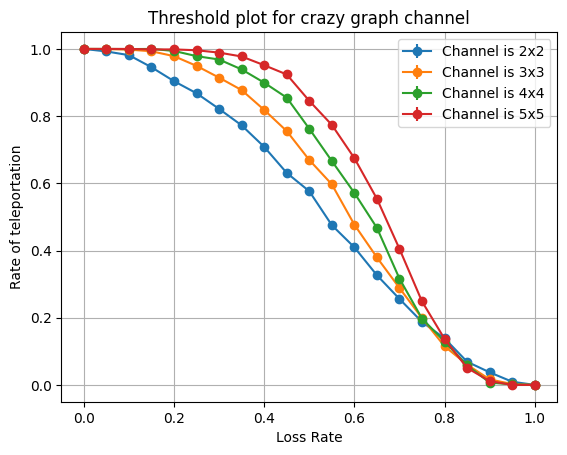

In [ ]:
from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed


def run_p(args):
    p, g, stabi, xlogi, zlogi, previous_meas, numq, gg, num_shots = args

    success = 0

    for _ in range(num_shots):
        lq = sample_lost_nodes(g, p)
        lost_cols = [node - 1 for node in lq]

        lost_qubits = [0] * (2 * numq)
        for c in lost_cols:
            lost_qubits[c] = 1
            lost_qubits[c + numq] = 1

        res = generalised_spf_logical(
            stabi,
            xlogi,
            zlogi,
            previous_meas,
            lost_qubits,
            gg,
            target_qubit=numq - 1
        )

        success += res["success"]

    return success / num_shots


plt.figure()


lost_prob = np.linspace(0,1,21)
for i in [2, 3, 4, 5]:
    # cha = "hexagonal"
    cha = "crazy graph"
    # g = hexagonal_lattice(i,i)
    g = crazy_graph(i,i)
    g = nx.to_numpy_array(g, dtype = np.uint16)
    #numq = g.shape[0]-1
    xlogi, zlogi, stabi = create_graph_code(g)
    T = GF2(stabi)
    numq=T.shape[1]//2
    gg = 1
    previous_meas = []
    previous_meas = [ta.paulistring2tableau(ele, numq) for ele in previous_meas]


    fail_list = []
    fit = []
    num_shots = 2000
    args = [
        (p, g, stabi, xlogi, zlogi,
            previous_meas, numq, gg, num_shots)
        for p in lost_prob
    ]

    fail_list = Parallel(n_jobs=-1)(
        delayed(run_p)(arg) for arg in args
    )

    fail_list = np.asarray(fail_list)
    yerr = np.sqrt(fail_list * (1 - fail_list) / num_shots)

    plt.title(f"Threshold plot for {cha} channel")
    plt.errorbar(
        lost_prob,
        fail_list,
        yerr=yerr,
        fmt="o-",
        label=f"Channel is {i}x{i}"
    )

    plt.xlabel("Loss Rate")
    plt.ylabel("Rate of teleportation")

plt.legend()
plt.grid()
# plt.savefig(f"{cha}_threshold_5"+".pdf", dpi=800, format="pdf", bbox_inches = 'tight')
plt.show()